### **Importing Libraries**

In [25]:
import os
import pywt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.io import Raw
from mne import Epochs, find_events, pick_types
from mne.filter import filter_data
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac


# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [26]:
# Load sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(raw_fname, preload=True)


### **Preprocessing**

In [27]:
# Filter the data
raw.filter(l_freq=0.5, h_freq=40, verbose=False)

# Determine the Nyquist frequency
nyquist_freq = raw.info['sfreq'] / 2

# Set notch filter frequencies to target 60 Hz and its harmonics (120, 180, 240 Hz)
notch_freqs = np.arange(60, nyquist_freq, 60)

# Apply the notch filter
raw.notch_filter(freqs=notch_freqs, picks="eeg", filter_length="auto", verbose=False)


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

In [28]:
# Denoising using Wavelet Transform
def wavelet_denoising(data, wavelet='db4', level=2):
    """Wavelet Transform Denoising"""
    denoised_data = []
    for epoch in data:
        denoised_epoch = []
        for ch_data in epoch:
            # Decompose signal into wavelet coefficients
            coeffs = pywt.wavedec(ch_data, wavelet, level=level)
            # Thresholding the coefficients (soft thresholding)
            thresholded_coeffs = [pywt.threshold(c, np.std(c) * 0.5, mode='soft') for c in coeffs]
            # Reconstruct the signal from the thresholded coefficients
            denoised_epoch.append(pywt.waverec(thresholded_coeffs, wavelet))
        denoised_data.append(np.array(denoised_epoch))
    return np.array(denoised_data)


### **Extracting Events and Creating Epochs**

C:\Users\lacom\AppData\Local\Temp\ipykernel_17084\298206401.py:7: RuntimeWarning: event 5 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);
C:\Users\lacom\AppData\Local\Temp\ipykernel_17084\298206401.py:7: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);


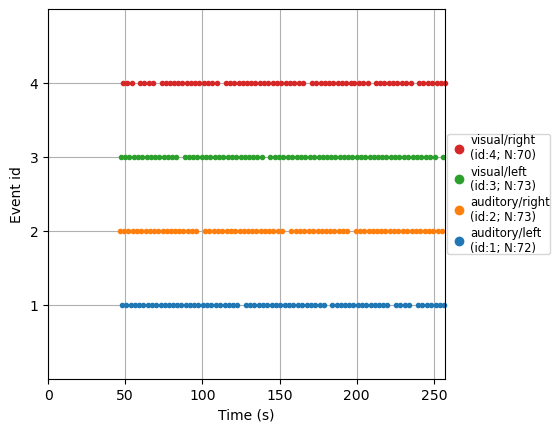

In [29]:
# Extract events 
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)


event_id = {"visual/left": 3, "visual/right": 4,
            "auditory/left": 1, "auditory/right": 2}
fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);

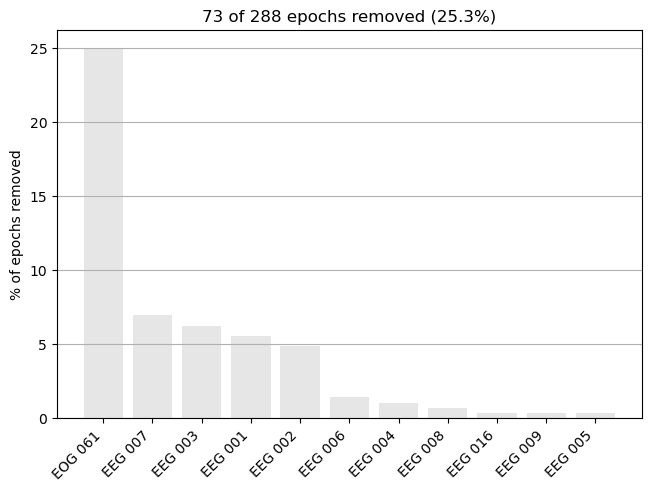

In [30]:

# Epochs parameters
tmin = -0.1  # Start of epoch in seconds
tmax = 0.4   # End of epoch in seconds
baseline = None  # No baseline correction
reject = dict(eeg=80e-6, eog=40e-6)
picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=True, stim=False, exclude='bads')

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, 
                    baseline=baseline, reject=reject, preload=True)


# Separate epochs for each event type
epochs_event1 = epochs['auditory/left']
epochs_event2 = epochs['auditory/right']
epochs_event3 = epochs['visual/left']
epochs_event4 = epochs['visual/right']


epochs.drop_bad()

fig = epochs.plot_drop_log()

### **Denoising**

In [31]:
# Apply wavelet denoising to epochs data
epochs_data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_timepoints)
denoised_data = wavelet_denoising(epochs_data, level=2)

# Update the epochs object with denoised data
epochs._data = denoised_data

In [32]:
# Accessing and indexing epochs by condition
evoked_auditory = epochs['auditory'].average().pick_types(eeg=True)
evoked_visual = epochs['visual'].average().pick_types(eeg=True)

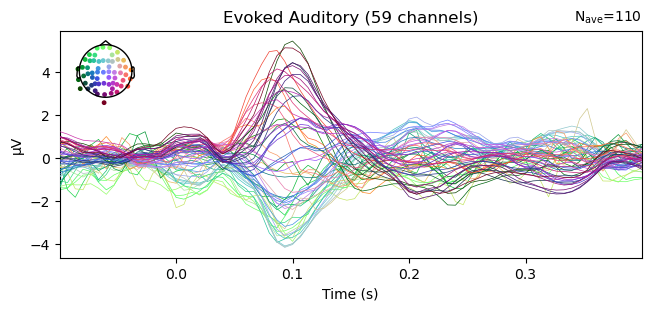

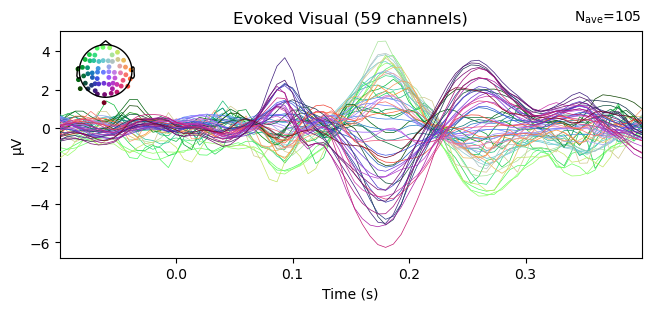

In [33]:
fig = evoked_auditory.plot(spatial_colors=True,titles='Evoked Auditory')
fig = evoked_visual.plot(spatial_colors=True,titles='Evoked Visual')

### Machine Learning

In [34]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore

In [35]:
#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
auditory_epochs = epochs['auditory']
visual_epochs = epochs['visual']

# Print information about the equalized epochs
print(auditory_epochs)
print(visual_epochs)

<Epochs | 98 events (all good), -0.1 – 0.4 s (baseline off), ~6.3 MiB, data loaded,
 'auditory/left': 49
 'auditory/right': 49>
<Epochs | 98 events (all good), -0.1 – 0.4 s (baseline off), ~6.3 MiB, data loaded,
 'visual/left': 49
 'visual/right': 49>


In [41]:
# Get the names of all EEG channels
eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch]

# Print the EEG channel names
print(eeg_channels)


['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']


In [46]:

def preprocess_epochs_to_dataframe(epochs, event_id, event_conditions, pick_eeg=True):
    """
    Preprocess EEG epochs data into a flattened DataFrame with channel-timepoint features and labels.
    
    Parameters:
    - epochs: The Epochs object containing EEG data (mne.Epochs).
    - event_id: A dictionary mapping event names to event IDs (e.g., {'auditory/left': 1, 'visual/right': 2}).
    - event_conditions: A list of event conditions to consider for labeling (e.g., ['auditory/left', 'visual/right']).
    - pick_eeg: Whether to select only EEG channels (default is True).
    
    Returns:
    - X_df: A pandas DataFrame with flattened EEG data and corresponding labels.
    """
    
    # Step 1: Select only EEG channels if specified
    if pick_eeg:
        epochs = epochs.pick_types(eeg=True)
    
    # Get the data (shape: [n_epochs, n_channels, n_timepoints])
    X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_timepoints)
    
    # Step 2: Create feature names (channel-timepoint pairs)
    feature_names = []
    n_channels = X.shape[1]
    n_timepoints = X.shape[2]

    for ch in range(n_channels):  # Iterate over EEG channels
        for t in range(n_timepoints):  # Iterate over time points
            feature_names.append(f"Channel_{ch}_Time_{t}")
    
    # Step 3: Flatten the data (preserving channel-timepoint structure)
    X_flattened = X.reshape(X.shape[0], -1)  # Shape: (n_epochs, n_channels * n_timepoints)

    # Step 4: Initialize the label array
    y = np.empty(len(epochs.events), dtype=int)
    
    # Step 5: Assign labels based on event conditions
    for condition in event_conditions:
        idx_condition = epochs.events[:, 2] == event_id[condition]
        y[idx_condition] = event_conditions.index(condition)  # Assign labels based on condition order
    
    # Step 6: Create a DataFrame with flattened data and feature names
    X_df = pd.DataFrame(X_flattened, columns=feature_names)
    
    # Step 7: Add the labels to the DataFrame (optional)
    X_df['label'] = y
    
    # Step 8: Return the DataFrame with features and labels
    return X_df



In [47]:
# Define the event conditions you want to label
event_conditions = ['auditory/left', 'auditory/right', 'visual/left', 'visual/right']

# Assuming 'epochs' is your MNE Epochs object
X_df = preprocess_epochs_to_dataframe(epochs, event_id, event_conditions)

# Check the first few rows of the resulting DataFrame
X_df.head()

,Channel_0_Time_0,Channel_0_Time_1,Channel_0_Time_2,Channel_0_Time_3,Channel_0_Time_4,Channel_0_Time_5,Channel_0_Time_6,Channel_0_Time_7,Channel_0_Time_8,Channel_0_Time_9,...,Channel_58_Time_67,Channel_58_Time_68,Channel_58_Time_69,Channel_58_Time_70,Channel_58_Time_71,Channel_58_Time_72,Channel_58_Time_73,Channel_58_Time_74,Channel_58_Time_75,label
0,-1.346084e-06,-2.666443e-06,-8.148640e-07,0.000004,5.578182e-06,9.936834e-07,-3.306765e-06,5.538776e-07,6.387133e-06,0.000008,...,-1.313177e-06,-8.536879e-07,8.912864e-08,5.251682e-07,4.199081e-07,6.729766e-08,-1.678721e-07,-2.262761e-09,-8.385558e-08,0
1,5.962565e-06,1.166038e-05,1.000872e-05,0.000003,-4.438997e-07,2.489002e-06,5.985047e-06,3.127930e-06,-2.841143e-06,-0.000002,...,-5.340046e-06,-5.657539e-06,-5.072147e-06,-4.723667e-06,-4.691199e-06,-3.434968e-06,-1.185150e-06,-4.633079e-08,6.221538e-08,3
2,-7.053419e-07,-7.825388e-07,8.649030e-07,0.000002,9.614580e-07,7.270510e-07,1.151449e-06,3.987590e-07,-3.531489e-06,-0.000006,...,6.730836e-07,9.593096e-07,4.872312e-07,7.666683e-09,-8.297210e-07,-7.799656e-07,3.042727e-07,4.827106e-07,-2.694489e-08,1
3,1.736400e-06,1.262265e-06,-5.182929e-08,-0.000002,-2.332151e-06,-5.696130e-07,-1.751333e-07,-6.740349e-07,2.373980e-08,0.000001,...,-6.492361e-07,-3.551354e-07,-5.704339e-08,3.911134e-07,9.302099e-07,1.596657e-06,2.403352e-06,2.732977e-06,2.536848e-06,2
4,1.635138e-06,-5.384274e-06,-4.019609e-06,0.000004,5.452208e-06,4.608202e-07,-1.099486e-06,1.397400e-06,1.131008e-06,-0.000002,...,-1.374372e-08,-1.264998e-08,2.939621e-09,9.101690e-09,2.558143e-09,9.512443e-10,-8.286748e-10,-1.761178e-09,1.465747e-10,0


In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Assuming 'X_df' is the DataFrame with flattened EEG data and labels
# And that 'y' is the array with the corresponding labels
X = X_df.drop(columns='label')  # Features (drop the label column)
y = X_df['label']  # Labels

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [38]:

# Step 2: Define the best hyperparameters based on grid search results
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

# Step 3: Set up the XGBoost classifier with the best hyperparameters
xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    **best_params  # Apply the best hyperparameters here
)

# Step 4: Fit the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = xgb.predict(X_test)

# Step 6: Evaluate the model performance using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with best hyperparameters: {accuracy:.4f}")


c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:06:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy with best hyperparameters: 0.9500


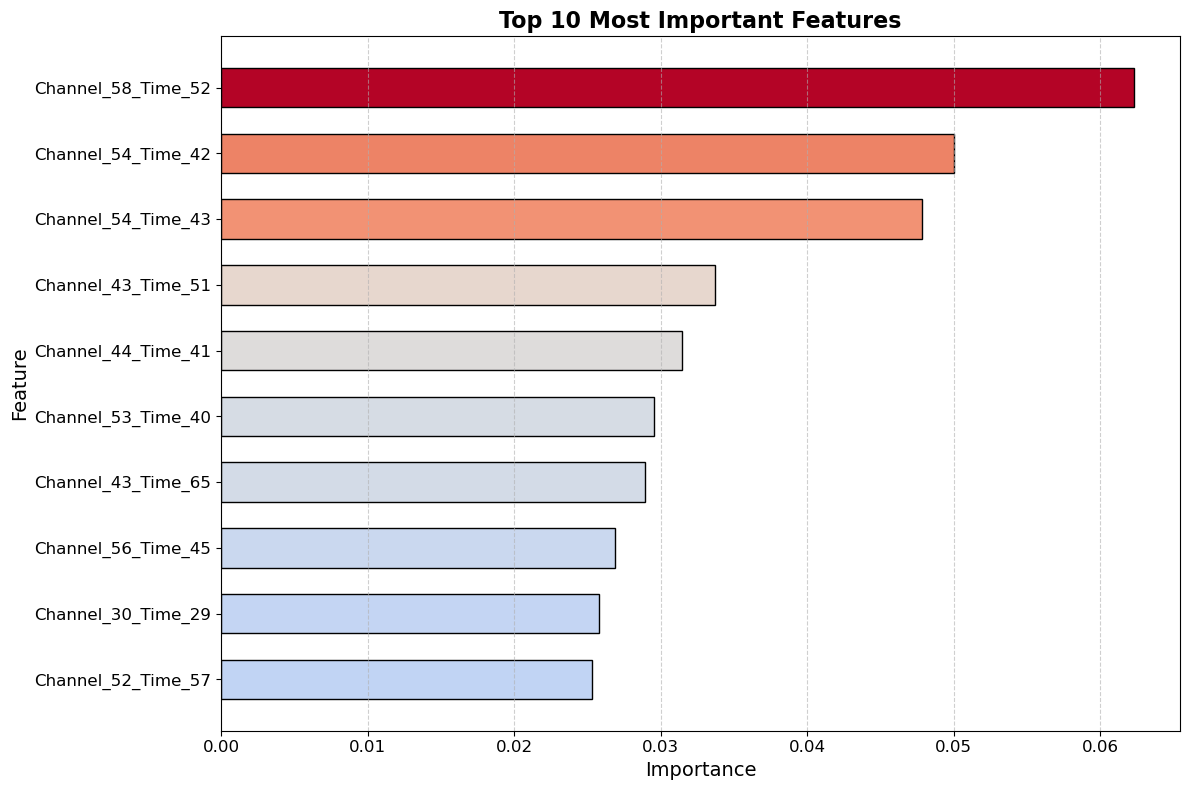

,feature,importance
4460,Channel_58_Time_52,0.062314
4146,Channel_54_Time_42,0.050002
4147,Channel_54_Time_43,0.047814
3319,Channel_43_Time_51,0.033707
3385,Channel_44_Time_41,0.031445
4068,Channel_53_Time_40,0.029542
3333,Channel_43_Time_65,0.028934
4301,Channel_56_Time_45,0.026863
2309,Channel_30_Time_29,0.025752
4009,Channel_52_Time_57,0.025285


In [53]:
# Get feature importance from the trained model
importances = xgb.feature_importances_

# Step 10: Create a DataFrame of feature importances (with channel-timepoint as the feature names)
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top 10 most important features
top_10_features = feature_importances_df.head(10)

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a color palette based on importance values (from light to dark)
bar_colors = sns.color_palette("coolwarm", as_cmap=True)

# Create the horizontal bar plot
bars = plt.barh(top_10_features['feature'], top_10_features['importance'], 
                color=bar_colors(top_10_features['importance'] / max(top_10_features['importance'])), 
                edgecolor='black', height=0.6)


# Make the title and labels more readable
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Invert the y-axis to display the most important feature at the top
plt.gca().invert_yaxis()

# Customize the grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Step 12: Optionally, output the top important features for further analysis
top_10_features
